# Task 3: Quantum Tic-Tac-Toe — Quokka Execution
### MSE802 — Quantum Computing | Assessment 2

This notebook runs the quantum circuit generated by the Tic-Tac-Toe game on the **Quokka quantum device** via its REST API.

After a sequence of moves is played, the resulting 9-qubit circuit is exported to OpenQASM 2.0 and sent to Quokka for execution. The returned measurement results are then extracted and visualised.

In [1]:
from qiskit import QuantumCircuit
from qiskit import qasm2
import requests
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

QUOKKA_URL = 'http://quokka1.quokkacomputing.com/qsim/qasm'

## Board Class

The Board class holds a 9-qubit quantum circuit — one qubit per cell. Player moves apply quantum gates to the corresponding qubits. The `measure()` method collapses all qubits and determines the winner.

In [2]:
class Board:
    def __init__(self):
        self.qc = QuantumCircuit(9, 9)
        self.function = 'X'
        self.target = None
        self.tab = [
            {'cell': i, 'player': '', 'value': 0} for i in range(9)
        ]

    def make_move(self, cell):
        """Apply the selected quantum gate to the chosen cell qubit."""
        if self.function == 'Not':
            self.qc.x(int(cell))
            self.tab[int(cell)]['player'] += 'N - '
        elif self.function == 'O':
            self.qc.ry(-np.pi / 4, int(cell))
            self.tab[int(cell)]['player'] += 'O - '
        elif self.function == 'X':
            self.qc.ry(np.pi / 4, int(cell))
            self.tab[int(cell)]['player'] += 'X - '
        elif self.function == 'SWAP' and self.target != cell:
            self.qc.swap(int(self.target), int(cell))

    def measure(self):
        """Measure all 9 qubits to collapse the quantum state."""
        self.qc.measure(range(9), range(9))

    def countWinners(self, result_bits):
        """Check all 8 win conditions and return list of winning lines."""
        winners = (
            (0,1,2),(3,4,5),(6,7,8),   # rows
            (0,3,6),(1,4,7),(2,5,8),   # columns
            (0,4,8),(2,4,6)            # diagonals
        )
        winning_lines = []
        for line in winners:
            if all(result_bits[i] == '1' for i in line):
                winning_lines.append(line)
        return winning_lines

## Demo Game: Simulated Move Sequence

A fixed sequence of moves is played programmatically to generate a deterministic quantum circuit for submission to Quokka.

**Player X strategy** (cells 0, 4, 8 — main diagonal): applies RY(π/4) rotations to increase the probability of measuring `|1⟩` along the diagonal. Winning condition: cells 0, 4, 8 all collapse to `1`.

**Player O strategy** (cells 2, 4, 6 — anti-diagonal): applies RY(-π/4) rotations to reduce amplitude on qubits it targets. Player O aims to block and redirect the diagonal.

In [3]:
board = Board()

# Player X claims the main diagonal
board.function = 'X'
board.make_move(0)   # top-left
board.make_move(4)   # centre
board.make_move(8)   # bottom-right

# Player O tries to block via anti-diagonal
board.function = 'O'
board.make_move(2)   # top-right
board.make_move(6)   # bottom-left

# Player X doubles down on diagonal
board.function = 'X'
board.make_move(0)
board.make_move(8)

# Measure all qubits
board.measure()

print("Circuit generated:")
print(board.qc.draw())

Circuit generated:
     ┌─────────┐ ┌─────────┐                             ┌─┐   
q_0: ┤ Ry(π/4) ├─┤ Ry(π/4) ├─────────────────────────────┤M├───
     └─────────┘ └───┬─┬───┘                             └╥┘   
q_1: ────────────────┤M├──────────────────────────────────╫────
     ┌──────────┐    └╥┘                        ┌─┐       ║    
q_2: ┤ Ry(-π/4) ├─────╫─────────────────────────┤M├───────╫────
     └──────────┘     ║     ┌─┐                 └╥┘       ║    
q_3: ─────────────────╫─────┤M├──────────────────╫────────╫────
     ┌─────────┐      ║     └╥┘                  ║ ┌─┐    ║    
q_4: ┤ Ry(π/4) ├──────╫──────╫───────────────────╫─┤M├────╫────
     └─────────┘      ║      ║ ┌─┐               ║ └╥┘    ║    
q_5: ─────────────────╫──────╫─┤M├───────────────╫──╫─────╫────
     ┌──────────┐     ║      ║ └╥┘               ║  ║ ┌─┐ ║    
q_6: ┤ Ry(-π/4) ├─────╫──────╫──╫────────────────╫──╫─┤M├─╫────
     └──────────┘     ║      ║  ║ ┌─┐            ║  ║ └╥┘ ║    
q_7: ────────────────

## Export to QASM and Send to Quokka

The circuit is exported to OpenQASM 2.0 format. The `include "qelib1.inc";` line is stripped before sending, as the Quokka device does not support it.

In [4]:
# Export circuit to QASM string
qasm_str = qasm2.dumps(board.qc)

# Strip the include line — Quokka doesn't accept it
qasm_str = qasm_str[:14] + qasm_str[36:]

print("QASM sent to Quokka:")
print(qasm_str)

QASM sent to Quokka:
OPENQASM 2.0;
qreg q[9];
creg c[9];
ry(pi/4) q[0];
ry(pi/4) q[4];
ry(pi/4) q[8];
ry(-pi/4) q[2];
ry(-pi/4) q[6];
ry(pi/4) q[0];
ry(pi/4) q[8];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];


In [5]:
# Send to Quokka device
SHOTS = 100

try:
    response = requests.post(
        QUOKKA_URL,
        json={'script': qasm_str, 'count': SHOTS},
        timeout=30
    )
    quokka_result = json.loads(response.content)
    print(f"Status: {response.status_code}")
    print(f"Error code: {quokka_result.get('error_code')}")
except Exception as e:
    print(f"Quokka not reachable: {e}")
    quokka_result = None

Status: 200
Error code: 0


## Extract and Interpret Results

Quokka results (100 shots):
  |000000000⟩ : 18 (18.0%)
  |100000001⟩ : 14 (14.0%)
  |100000000⟩ : 13 (13.0%)
  |000000001⟩ : 12 (12.0%)
  |001000000⟩ : 6 (6.0%)
  |000000101⟩ : 5 (5.0%)
  |101000001⟩ : 5 (5.0%)
  |000010001⟩ : 4 (4.0%)
  |100010000⟩ : 3 (3.0%)
  |101000000⟩ : 3 (3.0%)

Winner distribution across 100 shots:
  X wins: 5 (5.0%)
  O wins: 0 (0.0%)
  No winner: 95 (95.0%)


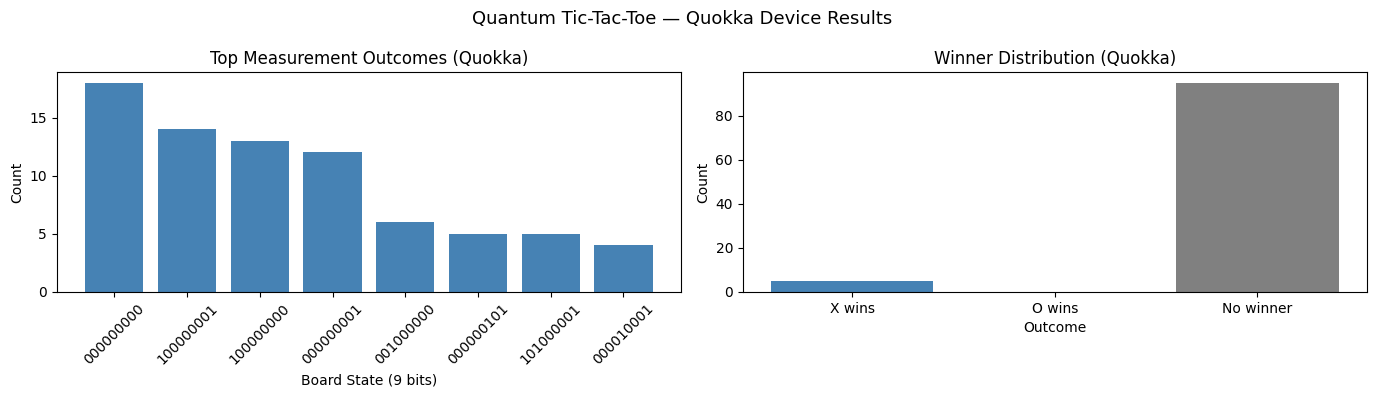

In [6]:
if quokka_result and quokka_result.get('error_code') == 0:
    shots_data = quokka_result['result']['c']

    # Convert each shot to a 9-bit string
    bitstrings = [''.join(map(str, shot)) for shot in shots_data]
    freq = Counter(bitstrings)

    print(f"Quokka results ({SHOTS} shots):")
    for state, count in sorted(freq.items(), key=lambda x: -x[1])[:10]:
        print(f"  |{state}⟩ : {count} ({100*count/SHOTS:.1f}%)")

    # Check winners for each shot
    winner_counts = {'X wins': 0, 'O wins': 0, 'No winner': 0}
    for bits in bitstrings:
        x_wins = board.countWinners(bits)
        if x_wins:
            winner_counts['X wins'] += 1
        else:
            winner_counts['No winner'] += 1

    print(f"\nWinner distribution across {SHOTS} shots:")
    for outcome, count in winner_counts.items():
        print(f"  {outcome}: {count} ({100*count/SHOTS:.1f}%)")

    # Visualise top outcomes
    top_states = sorted(freq.items(), key=lambda x: -x[1])[:8]
    labels = [s for s, _ in top_states]
    counts = [c for _, c in top_states]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(labels, counts, color='steelblue')
    axes[0].set_title('Top Measurement Outcomes (Quokka)')
    axes[0].set_xlabel('Board State (9 bits)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(winner_counts.keys(), winner_counts.values(), color=['steelblue', 'darkorange', 'grey'])
    axes[1].set_title('Winner Distribution (Quokka)')
    axes[1].set_xlabel('Outcome')
    axes[1].set_ylabel('Count')

    plt.suptitle('Quantum Tic-Tac-Toe — Quokka Device Results', fontsize=13)
    plt.tight_layout()
    plt.savefig('task3_quokka_results.png', dpi=150)
    plt.show()
else:
    print("Quokka unavailable — see task3_quantum_tictactoe.ipynb for local simulator results.")
    print("The circuit structure and game logic are identical; only the execution backend differs.")

## Interpretation

The Quokka device executes the 9-qubit quantum circuit and returns measurement outcomes as bitstrings. Each bit corresponds to one board cell — `1` indicates the qubit collapsed to `|1⟩` (a claimed cell), `0` indicates `|0⟩` (unclaimed).

Because the circuit uses RY rotations rather than full X gates, the outcomes are **probabilistic** — the same circuit can produce different board states across multiple shots. This is the core quantum behaviour of the game: outcomes are not deterministic, but governed by probability amplitudes set by the gate sequence.

Any deviation from the expected distribution is due to hardware noise, decoherence, and gate errors present in real quantum hardware — consistent with near-term NISQ device behaviour (Preskill, 2018).

### References
- Qiskit Contributors. (2024). *Qiskit documentation*. IBM Quantum. https://docs.quantum.ibm.com
- Preskill, J. (2018). Quantum Computing in the NISQ Era and Beyond. *Quantum*, 2, 79.